In [64]:
import matplotlib.pyplot as plt
from OptimalBattery.global_config import repo_dir,save_dir
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib as mpl
mpl.rcParams["pdf.fonttype"] = 42
from scipy.stats import pearsonr
from scipy.stats import sem
from scipy.stats import ttest_rel
import os

In [65]:
metrics = ['random','variance','log_det_mc','inverse_trace_mc']

custom_palette = {
    'random': 'black',
    'variance': '#0072B2',
    'variance_mc': '#009E73',
    'log_det_mc': '#E69F00',
    'inverse_trace_mc': '#D55E00'
}

custom_dashes = {
    'random': (1, 1),            # dotted
    'variance': (4, 2),              # dashed
    'variance_mc': (4, 2),           # dashed
    'log_det_mc': '',        # solid
    'inverse_trace_mc': '',  # solid
}

# parcellation simulation

In [66]:
eval_tsvs_dir = os.path.abspath(os.path.join(os.getcwd(),'..','eval_tsvs'))
saved_file = os.path.join(eval_tsvs_dir, 'parcellation_sim.tsv')
D = pd.read_csv(saved_file, sep='\t')
D = D[D['metric'].isin(metrics)]

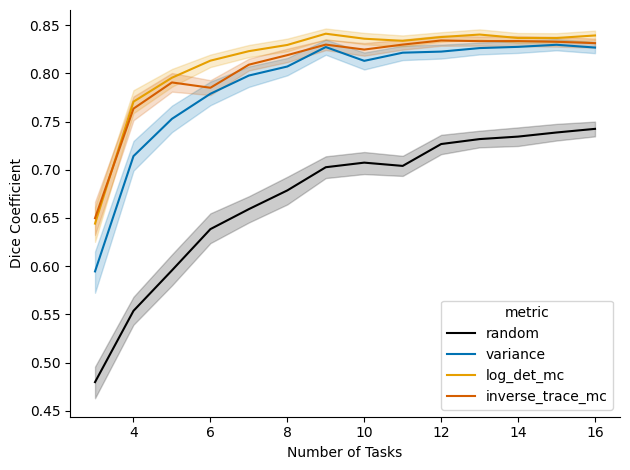

In [67]:
sns.lineplot(
    data=D,
    x="n_task",
    y="accuracy",
    hue="metric",
    palette=custom_palette,

)

plt.xlabel("Number of Tasks")
plt.ylabel("Dice Coefficient")
plt.tight_layout()
sns.despine()
# plt.savefig(f"{save_dir}/battery_criteria/sim_parcellate.pdf", format="pdf", bbox_inches="tight")
plt.show()

# connectivity simulation

In [68]:
eval_tsvs_dir = os.path.abspath(os.path.join(os.getcwd(),'..','eval_tsvs'))
saved_file = os.path.join(eval_tsvs_dir, 'connectivity_sim.tsv')
D = pd.read_csv(saved_file, sep='\t')
# defube metrics to plot
D = D[D['metric'].isin(metrics)]

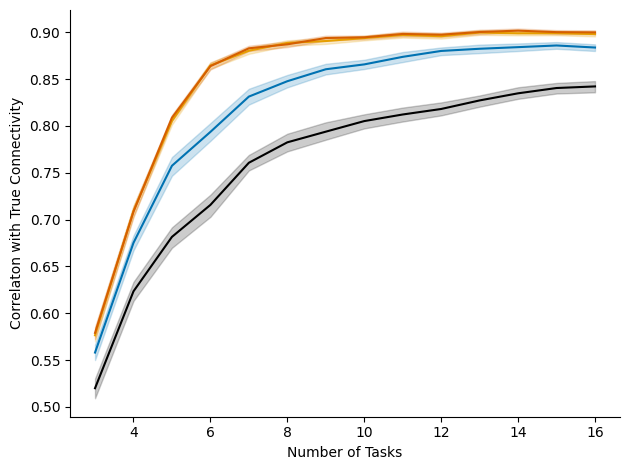

In [69]:
sns.lineplot(
    data=D,
    x="n_task",
    y="correlation",
    hue="metric",
    palette=custom_palette,
)

plt.xlabel("Number of Tasks")
plt.ylabel("Correlaton with True Connectivity")
plt.legend([],[], frameon=False)
plt.tight_layout()
sns.despine()
# plt.savefig(f"{save_dir}/battery_criteria/sim_connectivity.pdf", format="pdf", bbox_inches="tight")
plt.show()

# parcellation real (cortex)

In [70]:
eval_tsvs_dir = os.path.abspath(os.path.join(os.getcwd(),'..','eval_tsvs'))
saved_file = os.path.join(eval_tsvs_dir, 'real_parcellation_cortex_org.tsv')
D = pd.read_csv(saved_file, sep='\t')
D = D[D['metric'].isin(metrics)]
n_subs = 24
D["sub"] = (D.index % n_subs) + 1
D = D[D['roi']=='All Parcels']

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\barafat\\Documents\\GitHub\\OptimalBattery\\eval_tsvs\\real_parcellation_cortex_org.tsv'

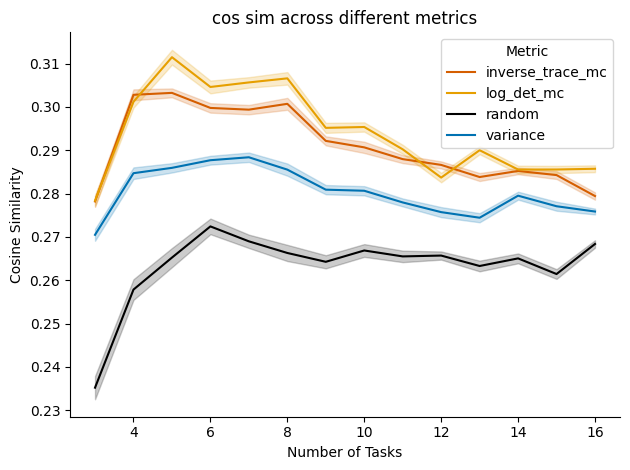

In [ ]:
# Step 1: compute the group mean per n_task
task_mean = D.groupby("n_task")["avg_cos_sim_per_subject"].transform("mean")

# Step 2: compute each subject’s mean within that n_task
subject_mean = D.groupby(["n_task", "sub"])["avg_cos_sim_per_subject"].transform("mean")

# Step 3 & 4: remove subject effect, add group mean
D["adjusted"] = D["avg_cos_sim_per_subject"] - subject_mean + task_mean

sns.lineplot(
    data=D,
    x="n_task",
    y="adjusted",
    hue="metric",
    errorbar='se',
    palette=custom_palette,
)


plt.xlabel("Number of Tasks")
plt.ylabel("Cosine Similarity")
plt.title(f"cos sim across different metrics")
sns.despine()
plt.legend(title="Metric")
plt.tight_layout()
plt.savefig(f"{save_dir}/battery_criteria/real_cortical_all.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
results = []

for n in D['n_task'].unique():
    sub_df = D[D['n_task'] == n]

    a = sub_df[sub_df['metric'] == 'log_det_mc'].sort_values('sub')['avg_cos_sim_per_subject']
    b = sub_df[sub_df['metric'] == 'variance'].sort_values('sub')['avg_cos_sim_per_subject']

    # Only run if both have the same subjects
    if len(a) == len(b):
        t, p = ttest_rel(a, b)
        results.append([n, t, p])

res_df = pd.DataFrame(results, columns=['n_task', 't', 'p'])
print(res_df)

    n_task          t             p
0        3   3.987939  5.796432e-04
1        4   7.333244  1.846132e-07
2        5  11.849230  2.843384e-11
3        6   8.083000  3.591450e-08
4        7   8.945226  5.994684e-09
5        8   8.241240  2.566689e-08
6        9   8.070715  3.686863e-08
7       10   8.892598  6.668162e-09
8       11   7.228106  2.336441e-07
9       12   3.749031  1.046924e-03
10      13   9.119825  4.221614e-09
11      14   3.841451  8.333167e-04
12      15   5.955595  4.512826e-06
13      16   7.995708  4.328863e-08


# parcellation real (cerebellum)

In [71]:
eval_tsvs_dir = os.path.abspath(os.path.join(os.getcwd(),'..','eval_tsvs'))
saved_file = os.path.join(eval_tsvs_dir, 'connectivity_real_1t2_10000.tsv')
D = pd.read_csv(saved_file, sep='\t')
D = D[D['metric'].isin(metrics)]
n_subs = 24
D["sub"] = (D.index % n_subs) + 1
# D = D[D['roi']=='all']


In [73]:
D

,n_task,metric,roi,avg_correlation_per_subject,sub
0,3,inverse_trace_mc,cortex-cereebellum,0.228844,1
1,3,inverse_trace_mc,cortex-cereebellum,0.098824,2
2,3,inverse_trace_mc,cortex-cereebellum,0.132398,3
3,3,inverse_trace_mc,cortex-cereebellum,0.240132,4
4,3,inverse_trace_mc,cortex-cereebellum,0.188107,5
...,...,...,...,...,...
1651,16,variance,cortex-cereebellum,0.323759,20
1652,16,variance,cortex-cereebellum,0.277304,21
1653,16,variance,cortex-cereebellum,0.312300,22
1654,16,variance,cortex-cereebellum,0.265931,23


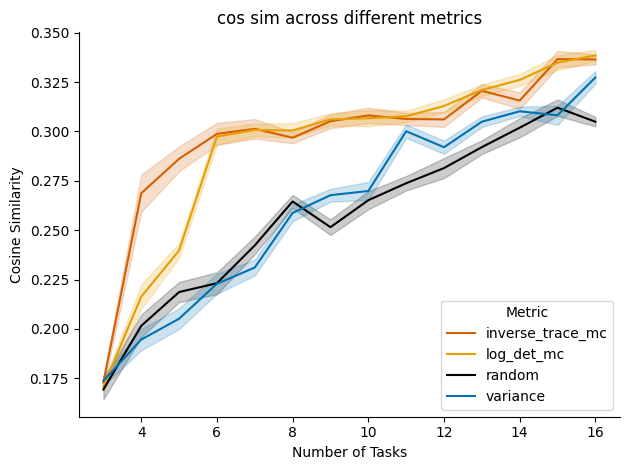

In [74]:
# Step 1: compute the group mean per n_task
task_mean = D.groupby("n_task")["avg_correlation_per_subject"].transform("mean")

# Step 2: compute each subject’s mean within that n_task
subject_mean = D.groupby(["n_task", "sub"])["avg_correlation_per_subject"].transform("mean")

# Step 3 & 4: remove subject effect, add group mean
D["adjusted"] = D["avg_correlation_per_subject"] - subject_mean + task_mean

sns.lineplot(
    data=D,
    x="n_task",
    y="adjusted",
    hue="metric",
    errorbar='se',
    palette=custom_palette,
)


plt.xlabel("Number of Tasks")
plt.ylabel("Cosine Similarity")
plt.title(f"cos sim across different metrics")
sns.despine()
plt.legend(title="Metric")
plt.tight_layout()
plt.savefig(f"{save_dir}/battery_criteria/real_cerebellar_all.pdf", format="pdf", bbox_inches="tight")
plt.show()

# connectivity real

In [ ]:
eval_tsvs_dir = os.path.abspath(os.path.join(os.getcwd(),'..','eval_tsvs'))
saved_file = os.path.join(eval_tsvs_dir, 'real_connectivity_org.tsv')
D = pd.read_csv(saved_file, sep='\t')
# defube metrics to plot
D = D[D['metric'].isin(metrics)]
n_subs = 24
D["sub"] = (D.index % n_subs) + 1

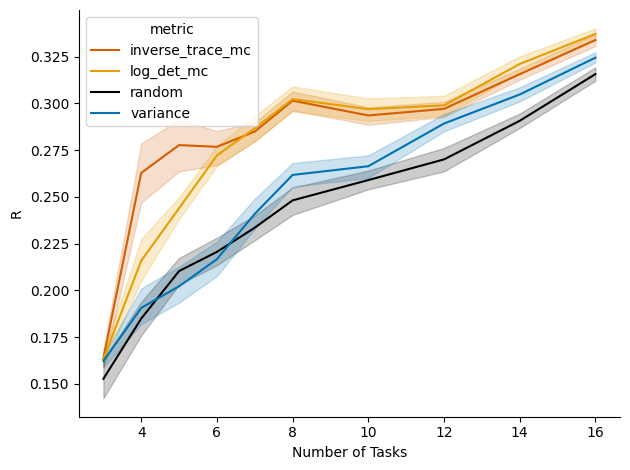

In [ ]:
# Step 1: compute the group mean per n_task
task_mean = D.groupby("n_task")["avg_correlation_per_subject"].transform("mean")

# Step 2: compute each subject’s mean within that n_task
subject_mean = D.groupby(["n_task", "sub"])["avg_correlation_per_subject"].transform("mean")

# Step 3 & 4: remove subject effect, add group mean
D["adjusted"] = D["avg_correlation_per_subject"] - subject_mean + task_mean

sns.lineplot(
    data=D,
    x="n_task",
    y="adjusted",
    hue="metric",
    palette=custom_palette,
)

plt.xlabel("Number of Tasks")
plt.ylabel("R")
# remove legend 
plt.tight_layout()
sns.despine()
plt.savefig(f"{save_dir}/battery_criteria/real_connectivity.pdf", format="pdf", bbox_inches="tight")
plt.show()